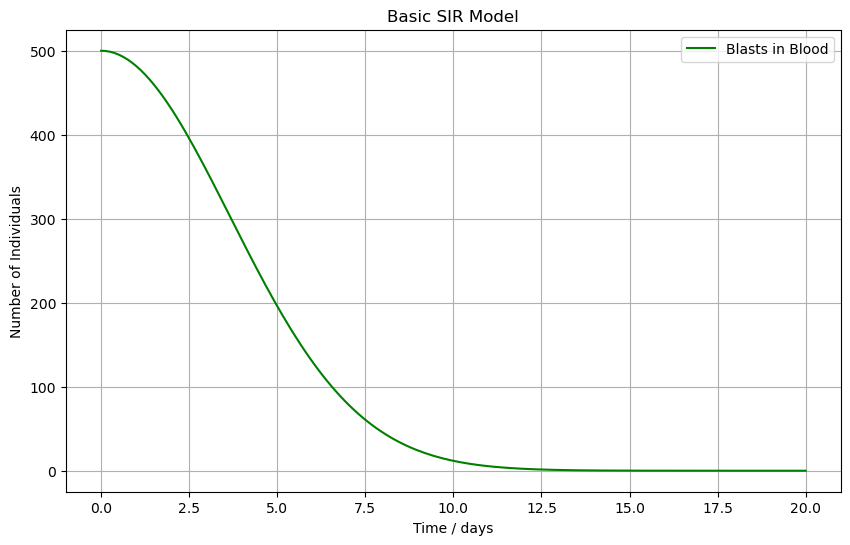

In [21]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
'''
    
    Xl1 = leukemic blasts in bone marrow
    Xl2 = leukemic blasts in the blood
    c1 and c2 = factor that modulates cytokine feedback, 0.1
    a1 = Fraction of self-renewal of leukemic cells, 0.875
    p1 = growth rate of leukemic cells, 0.1
    d2 = death rate of blasts in blood, 2.3
'''
def Aza_Effect(y,t):
 
    return I*1.1*(1/(t+0.000001))
Xl1 = 500
Xl2=0

def blast_pop(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):#Blast population model in two compartments
     Xl1,Xl2 = y
     I = 75 #mg dosage of azacitidine
     Eblast = I*(t)*0.001
     #klc = 1/(1+c1*Xwbc+c2*Xl2) #the suppressive influence from nuetrophils and blasts in the blood
     #dXl1dt = (a1 - Eblast)*Xl1 #change in leukemia cells in bone marrow 
     dXl1dt = Xl1*(-Eblast)
     dXl2dt = 2*(1-a1)*p1*Xl1 - (d2*Xl2) #change in leukemia cells in blood
     return [dXl1dt, dXl2dt]

t = np.linspace(0,20, 160)    
y0 = Xl1,Xl2
ret = odeint(blast_pop,y0,t)
Xl1,Xl2 = ret.T
plt.figure(figsize=(10, 6))
#plt.plot(t, Xpr, 'b', label=' proliferating cells in blood')
#plt.plot(t, Xl2, 'r', label='Blast in marrow')
plt.plot(t, Xl1, 'g', label='Blasts in Blood')
plt.title('Basic SIR Model')
plt.xlabel('Time / days')
plt.ylabel('Number of Individuals')
plt.legend()
plt.grid(True)
plt.show()